# Julia sets

Install the `sh` module if it is not installed since this is a bit off the beaten track.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import psutil
try:
    import sh
except ModuleNotFoundError:
    print('installing sh using pip')
    !pip install sh
    import sh
import time

Download the source code from GitHub if it is not in the current working directory.

In [6]:
julia_src = Path.cwd() / 'julia_omp.f90'
if not julia_src.exists():
    sh.wget('https://raw.githubusercontent.com/gjbex/Python-for-systems-programming/refs/heads/master/hands-on/julia_omp.f90')

Compile and build the application.

In [3]:
application = 'julia.exe'

In [4]:
_ = sh.gfortran('-O2', '-fopenmp', '-o', application, 'julia_omp.f90', '-lm')

Since the current working directory is not in the `PATH` environment variable, and the executable has a `.` in its name, a command has to be created.

In [5]:
julia = sh.Command(Path.cwd() / application)

Execute the application in the background and monitor user and system time and memory (RSS, Resident Set Size).

In [8]:
computation = julia('2000', _bg=True)

In [9]:
process = psutil.Process(pid=computation.pid)
while psutil.pid_exists(process.pid):
    times = process.cpu_times()
    memory = process.memory_info()
    print(f'user: {times.user}, sys: {times.system}, CPU: {process.cpu_percent()} %, rss: {memory.rss} bytes')
    time.sleep(0.5)

user: 1.31, sys: 0.31, CPU: 0.0 %, rss: 82444288 bytes
user: 3.18, sys: 0.32, CPU: 375.3 %, rss: 82575360 bytes


Just for fun, plot the output.

In [10]:
data_file = 'julia.txt'

In [11]:
data = np.genfromtxt(data_file)

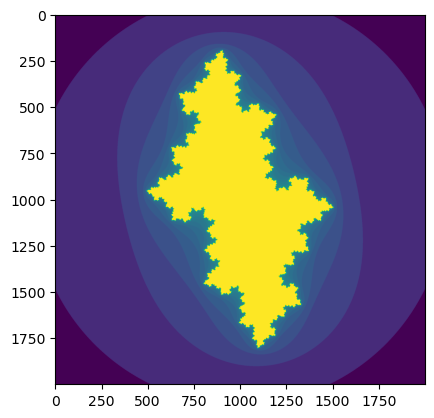

In [12]:
_ = plt.imshow(data)

Cleaning up the artifacts created in this notebook.

In [13]:
for file in map(Path, [data_file, application]):
    file.unlink()